# Step 3 — Exploratory correlation: ACC magnitude vs HR-estimation error

**Question:** How well does per-window accelerometer magnitude predict per-window HR-estimation error?

**Pre-processing (new in this step, lives in [`acc_features.py`](acc_features.py)):**
For each 8 s window we subtract each ACC axis's own mean, then take the per-sample 3-axis magnitude, then the window RMS. This removes the ~1 g gravity DC and leaves motion-only energy. A stationary wrist now reads ≈ 0, not ≈ 1.

### What this notebook does
1. **3.1** Load 22 recordings, run the HR estimator from Step 2 (per-window `abs_error`), compute AC-only ACC RMS per window.
2. **3.2** Demean sanity check — visualize one window raw → demeaned → magnitude.
3. **3.3** **Main figure** — 1×4 scatter grid: per-window \|error\| vs per-window AC-only ACC RMS (Pooled / T1 / T2 / T3), Pearson *r* and Spearman ρ per panel.
4. **3.4** Correlation summary table (Pearson + Spearman with p-values, pooled and per-group).
5. **3.5** Per-recording scatter (22 points): mean \|error\| vs mean AC-only RMS.
6. **3.6** Per-recording mean \|error\| bars, sorted by mean AC-only RMS (the monotonic-trend check from the spec).
7. **3.7** Same pooled scatter with `log1p(error)` on the y-axis — reveals the bulk near-zero that the linear view squashes.

### Why Spearman ρ is the headline
Per-window errors are heavy-tailed (median ≈ 1 BPM, max > 100). Pearson *r* is pulled by a handful of extreme outliers; Spearman ρ (rank-based) describes the monotonic trend — the one the paper should cite.

> **Kernel:** select `Python (ppg-entropy)` before running.


In [1]:
import os
from pathlib import Path

# Keep Matplotlib/fontconfig caches in the project so imports do not stall on
# unwritable default cache directories inside the notebook environment.
_cache_root = Path.cwd() / '.cache'
(_cache_root / 'matplotlib').mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(_cache_root / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(_cache_root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr

from data_loader import (
    FS, WIN_SAMPLES, SHIFT,
    GROUP_COLORS, GROUP_LABELS,
    load_all_recordings,
)
from hr_estimator import evaluate_all
from acc_features import attach_ac_rms, demean_window

%matplotlib inline
plt.rcParams['figure.dpi'] = 110


## 3.1 — Load data, run HR estimator, compute per-window AC-only ACC RMS

Three calls. All the heavy lifting happens in the three modules. `attach_ac_rms` mutates each recording dict in-place, adding `acc_rms_ac_windows` and `mean_acc_rms_ac`.

**Expected output:**
- `Loaded 22 recordings.`
- `Loaded 22 HR-evaluation results.`
- Both should be 22, no errors
- Printed counts per group: T1 → 1768 windows, T2 → 511 windows, T3 → 817 windows (pooled total 3096)


In [2]:
recordings = load_all_recordings(verbose=False)
print(f'Loaded {len(recordings)} recordings.')

attach_ac_rms(recordings)
results = evaluate_all(recordings)
print(f'Loaded {len(results)} HR-evaluation results.')

# Pool per-window arrays, aligned 1:1 between recordings and results
err_per_win = []
mag_per_win = []
grp_per_win = []
rec_per_win = []
for rec, res in zip(recordings, results):
    n = len(res['abs_error'])
    err_per_win.append(res['abs_error'])
    mag_per_win.append(rec['acc_rms_ac_windows'][:n])
    grp_per_win.append(np.full(n, rec['group']))
    rec_per_win.append(np.full(n, rec['rec_id']))
err_per_win = np.concatenate(err_per_win)
mag_per_win = np.concatenate(mag_per_win)
grp_per_win = np.concatenate(grp_per_win)
rec_per_win = np.concatenate(rec_per_win)
print(f'Pooled windows: {len(err_per_win)}')
for grp in ('T1', 'T2', 'T3'):
    n = int((grp_per_win == grp).sum())
    print(f'  {GROUP_LABELS[grp]:30s}  n={n}')


Loaded 22 recordings.
Loaded 22 HR-evaluation results.
Pooled windows: 3096
  T1 — treadmill                  n=1768
  T2 — mixed arm exercise         n=511
  T3 — boxing                     n=817


## 3.2 — Pre-processing sanity check (one window)

Pick one representative 8 s window and walk through the pipeline visually:

1. Raw ACC axes (gravity offsets visible — one axis sits near ±1 g depending on wrist orientation)
2. Demeaned ACC axes (all three now centered on 0)
3. Per-sample 3-axis magnitude of the demeaned signal

**Expected output:**
- Three stacked panels, 8 s of data each
- Panel 1: three traces around different non-zero baselines (gravity along one axis in particular)
- Panel 2: same three traces but all centered on 0
- Panel 3: single motion-only magnitude curve, baseline near 0 with peaks where motion happens
- Two RMS numbers printed: raw (includes gravity) and AC-only — **raw should be larger** because gravity adds a constant ~1 g
- If the three panel-2 traces are not centered on 0, the demean is broken — flag it


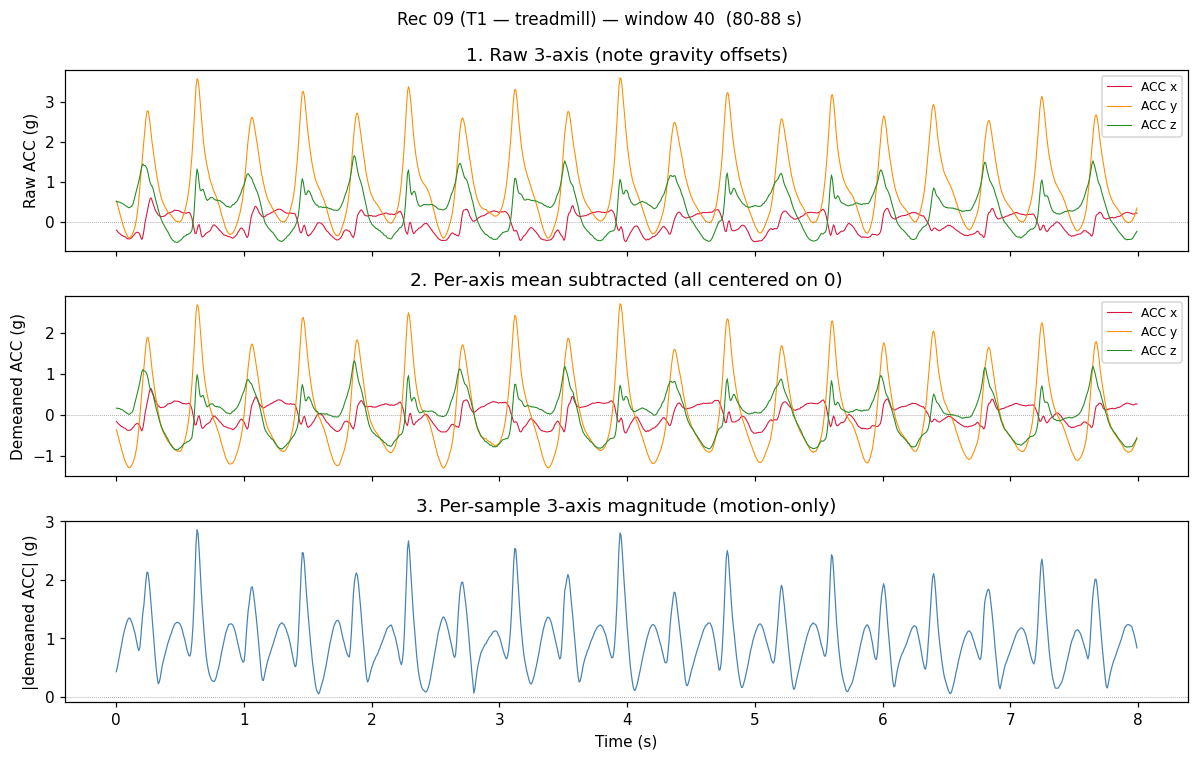

Raw RMS       (includes ~1 g gravity): 1.462 g
AC-only RMS   (gravity removed):       1.109 g
Difference (gravity contribution):      0.353 g


In [ ]:
# Pick one mid-recording window from rec 9 (T1 treadmill, clean-case) as exemplar.
# Change `demo_rec_id` / `demo_win_idx` to inspect different windows.
demo_rec_id  = 15
demo_win_idx = 40
rec = next(r for r in recordings if r['rec_id'] == demo_rec_id)

start = demo_win_idx * SHIFT
seg   = rec['acc'][:, start : start + WIN_SAMPLES]   # 3 × 1000
seg_dm = demean_window(seg)
mag_raw = np.sqrt(np.sum(seg**2,    axis=0))
mag_ac  = np.sqrt(np.sum(seg_dm**2, axis=0))
t       = np.arange(WIN_SAMPLES) / FS

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
fig.suptitle(f"Rec {demo_rec_id:02d} ({GROUP_LABELS[rec['group']]}) — window {demo_win_idx}  ({demo_win_idx*2}-{demo_win_idx*2+8} s)",
             fontsize=11)

for i, (label, color) in enumerate(zip(['ACC x', 'ACC y', 'ACC z'],
                                       ['crimson', 'darkorange', 'forestgreen'])):
    axes[0].plot(t, seg[i, :], lw=0.7, color=color, label=label)
axes[0].axhline(0, color='grey', lw=0.5, linestyle=':')
axes[0].set_ylabel('Raw ACC (g)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].set_title('1. Raw 3-axis (note gravity offsets)')

for i, (label, color) in enumerate(zip(['ACC x', 'ACC y', 'ACC z'],
                                       ['crimson', 'darkorange', 'forestgreen'])):
    axes[1].plot(t, seg_dm[i, :], lw=0.7, color=color, label=label)
axes[1].axhline(0, color='grey', lw=0.5, linestyle=':')
axes[1].set_ylabel('Demeaned ACC (g)')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].set_title('2. Per-axis mean subtracted (all centered on 0)')

axes[2].plot(t, mag_ac, lw=0.8, color=GROUP_COLORS[rec['group']])
axes[2].axhline(0, color='grey', lw=0.5, linestyle=':')
axes[2].set_ylabel('|demeaned ACC| (g)')
axes[2].set_xlabel('Time (s)')
axes[2].set_title('3. Per-sample 3-axis magnitude (motion-only)')

plt.tight_layout()
plt.show()

rms_raw = float(np.sqrt(np.mean(mag_raw**2)))
rms_ac  = float(np.sqrt(np.mean(mag_ac**2)))
print(f'Raw RMS       (includes ~1 g gravity): {rms_raw:.3f} g')
print(f'AC-only RMS   (gravity removed):       {rms_ac:.3f} g')
print(f'Difference (gravity contribution):      {rms_raw - rms_ac:.3f} g')


## 3.3 — Main figure: per-window \|error\| vs AC-only ACC RMS

Four scatter plots side-by-side — **Pooled | T1 | T2 | T3** — with identical axes so the group patterns are directly comparable. Each panel carries its Pearson *r* and Spearman ρ (with p-values).

- Small markers with `alpha=0.25` so density is visible where points pile up
- Gray dashed line = linear least-squares fit (visual aid only; don't read strength off it because of the heavy tail)
- **Read the Spearman ρ, not the regression slope**

**Expected output:**
- 4 subplots, same axes (x: 0–~2 g AC-only RMS, y: 0–~130 BPM \|error\|)
- **Pooled:** Pearson r ≈ +0.20, Spearman ρ ≈ +0.25 → weak positive trend overall
- **T1 treadmill:** r ≈ +0.29, ρ ≈ +0.27 → weak positive
- **T2 mixed arm:** r ≈ +0.33, ρ ≈ +0.37 → weakest-to-moderate positive
- **T3 boxing:** r ≈ −0.04, ρ ≈ +0.05 → **essentially zero** — magnitude carries no information about which boxing windows will fail. This is a key finding.
- If any panel is a perfect straight line or all points at y=0, something is broken — flag it.


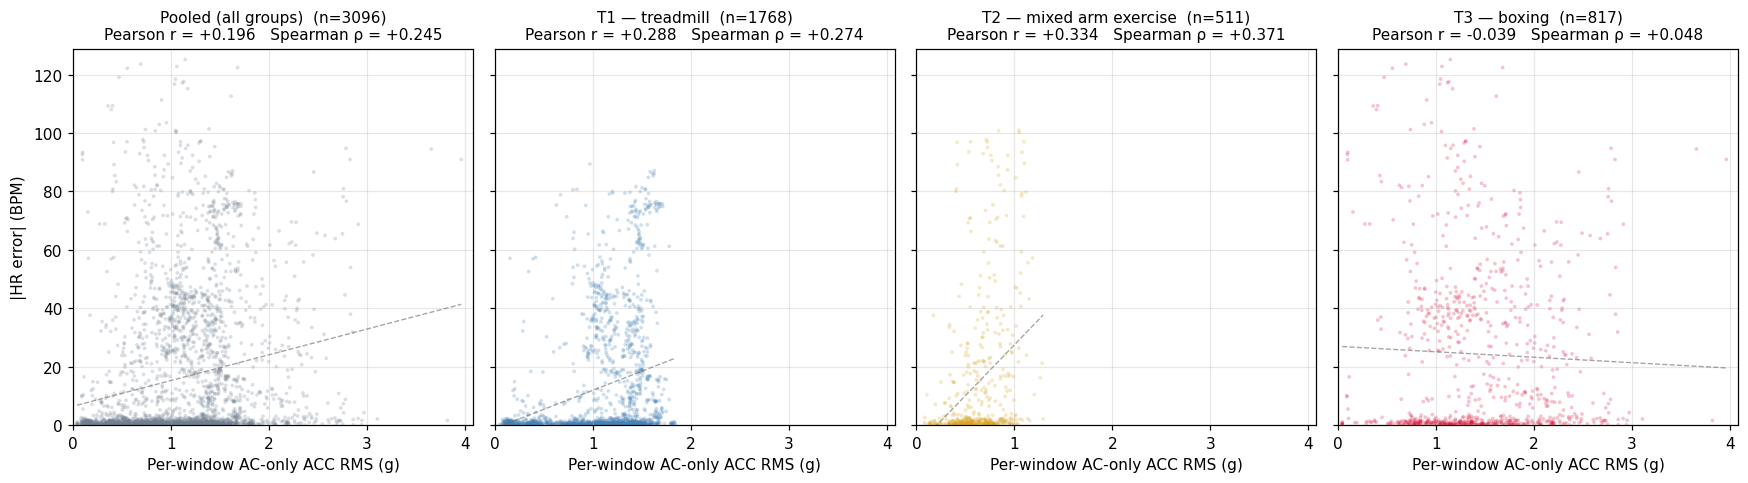

In [4]:
def scatter_and_stats(ax, x, y, color, title):
    r, rp = pearsonr(x, y)
    s, sp = spearmanr(x, y)
    ax.scatter(x, y, s=6, alpha=0.25, color=color, edgecolors='none')
    # Light dashed least-squares line (visual aid — doesn't reflect strength given heavy tail)
    if len(x) >= 2:
        slope, intercept = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 50)
        ax.plot(xs, slope*xs + intercept, lw=0.9, color='dimgray', linestyle='--', alpha=0.6)
    ax.set_title(f'{title}  (n={len(x)})\n'
                 f'Pearson r = {r:+.3f}   Spearman ρ = {s:+.3f}',
                 fontsize=10)
    ax.grid(alpha=0.3)

x_max = mag_per_win.max() * 1.03
y_max = err_per_win.max() * 1.03

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharex=True, sharey=True)

scatter_and_stats(axes[0], mag_per_win, err_per_win,
                  color='slategray', title='Pooled (all groups)')
for ax, grp in zip(axes[1:], ('T1', 'T2', 'T3')):
    mask = grp_per_win == grp
    scatter_and_stats(ax, mag_per_win[mask], err_per_win[mask],
                      color=GROUP_COLORS[grp], title=GROUP_LABELS[grp])

for ax in axes:
    ax.set_xlabel('Per-window AC-only ACC RMS (g)')
axes[0].set_ylabel('|HR error| (BPM)')
axes[0].set_xlim(0, x_max)
axes[0].set_ylim(0, y_max)

plt.tight_layout()
plt.show()


## 3.4 — Correlation summary table

Same numbers as the per-panel annotations in 3.3, collected into a clean table. This is the format the paper's Table 1 will pull from.

**Expected output:**
- Four rows: Pooled, T1, T2, T3
- Columns: n, Pearson r, Pearson p, Spearman ρ, Spearman p
- p-values should be effectively 0 for any |ρ| > 0.1 at n=500+ (i.e. the trends are statistically significant even when weak in effect size)
- Spot check: if T3's Spearman p is small (< 0.05) but |ρ| ≈ 0.05, that means "statistically significant but practically meaningless" — note it in the paper


In [5]:
rows = []
def add_row(label, x, y):
    r, rp = pearsonr(x, y)
    s, sp = spearmanr(x, y)
    rows.append(dict(label=label, n=len(x), r=r, rp=rp, rho=s, sp=sp))

add_row('Pooled (all groups)', mag_per_win, err_per_win)
for grp in ('T1', 'T2', 'T3'):
    mask = grp_per_win == grp
    add_row(GROUP_LABELS[grp], mag_per_win[mask], err_per_win[mask])

hdr = f"{'Slice':30s}  {'n':>5}  {'Pearson r':>10}  {'p':>10}  {'Spearman ρ':>11}  {'p':>10}"
print(hdr)
print('-' * len(hdr))
for r in rows:
    print(f"{r['label']:30s}  {r['n']:>5}  {r['r']:>+10.3f}  {r['rp']:>10.3g}  {r['rho']:>+11.3f}  {r['sp']:>10.3g}")


Slice                               n   Pearson r           p   Spearman ρ           p
--------------------------------------------------------------------------------------
Pooled (all groups)              3096      +0.196    2.95e-28       +0.245    1.66e-43
T1 — treadmill                   1768      +0.288    4.26e-35       +0.274    1.04e-31
T2 — mixed arm exercise           511      +0.334    8.68e-15       +0.371    3.84e-18
T3 — boxing                       817      -0.039       0.265       +0.048       0.167


## 3.5 — Per-recording scatter (22 points, three error summaries)

Three side-by-side scatter plots, one per error-summary statistic, all against per-recording mean AC-only ACC RMS:

1. **mean MAE** vs mean AC-only RMS
2. **median per-window error** vs mean AC-only RMS
3. **high-error window fraction** (% of windows with `|err| > threshold`) vs mean AC-only RMS

22 dots in each panel, coloured by group, with rec_id labels and Pearson r / Spearman ρ annotated in the panel title.

**Why three panels:** MAE is sensitive to a few catastrophic-failure windows; median is robust to those (typical-case behaviour); the high-error fraction captures *how often* failures occur, normalized for differing recording lengths so the 22 recordings are directly comparable.

**Expected output:**
- T1 cluster: mid-range x (1.0–1.3 g)
- T2 cluster: leftmost x (0.5–0.7 g)
- T3 cluster: rightmost x (1.1–1.7 g), highest y in all three panels
- Per-panel correlations printed in titles. Magnitude vs MAE is the strongest of the three (~+0.35), median tends to be similar or slightly weaker, high-error fraction tracks MAE closely.
- The third panel's y-axis is fixed to 0–100 %, so absolute heights *are* comparable across recordings (unlike with raw counts).


In [ ]:
rec_ids   = [r['rec_id']         for r in recordings]
mean_mag  = [r['mean_acc_rms_ac'] for r in recordings]
mean_mae  = [r['mae']             for r in results]
mean_med  = [r['median_error']    for r in results]
n_high    = [r['n_high_error']    for r in results]
n_win     = [len(r['abs_error'])  for r in results]
pct_high  = [100.0 * n_high[i] / n_win[i] for i in range(len(results))]
threshold = results[0]['high_error_threshold']
grp_col   = [GROUP_COLORS[r['group']] for r in recordings]

def _scatter(ax, x, y, ylabel, title, ylim=None):
    ax.scatter(x, y, c=grp_col, s=55, edgecolor='white', linewidth=0.7)
    for xi, yi, rid in zip(x, y, rec_ids):
        ax.annotate(str(rid), (xi, yi), fontsize=6.5, color='dimgray',
                    xytext=(4, 2), textcoords='offset points')
    rr, rp = pearsonr(x, y); ss, sp = spearmanr(x, y)
    ax.set_title(f'{title}\nPearson r = {rr:+.3f} (p={rp:.3g})\nSpearman ρ = {ss:+.3f} (p={sp:.3g})',
                 fontsize=9.5)
    ax.set_xlabel('Per-recording mean AC-only ACC RMS (g)')
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7))
_scatter(axes[0], mean_mag, mean_mae, 'Mean |HR error| (BPM)',          'Mean MAE')
_scatter(axes[1], mean_mag, mean_med, 'Median |HR error| (BPM)',        'Median error')
_scatter(axes[2], mean_mag, pct_high, f'% windows |err| > {threshold:.0f} BPM',
         f'High-error window fraction (>{threshold:.0f} BPM)', ylim=(0, 100))

handles = [mpatches.Patch(color=GROUP_COLORS[g], label=GROUP_LABELS[g]) for g in ('T1', 'T2', 'T3')]
axes[-1].legend(handles=handles, loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()


## 3.6 — Per-recording error metrics, sorted by AC-only RMS

Three vertically-stacked bar charts, each with the 22 recordings reordered left → right by ascending mean AC-only RMS. The top panel is mean MAE, middle is median per-window error, **bottom is the high-error window count expressed as a percentage of the recording's total windows** (so recordings with different lengths are directly comparable). Colour still tracks activity group, and the x-axis (AC-only RMS values) is shared across all three so the same recording sits in the same column in every panel.

This is the original spec's "monotonic-trend check" — generalized to all three error metrics so you can see which is more / less monotonic with magnitude.

**Expected output:**
- All three panels show a *weak* upward trend with magnitude (recording IDs roughly cluster T2 → T1 → T3 from left to right)
- **MAE panel** has the most variance (a few extreme spikes) — heavy-tail effect
- **Median panel** is much smoother — most recordings have median < 5 BPM, only T3 boxing visibly elevated
- **High-error fraction panel** (y-axis 0–100 %) is the most monotonic — failure *rate* tracks magnitude better than failure *amount*. Typical values: T1 ≈ 0–60 %, T2 ≈ 10–70 %, T3 ≈ 30–80 %.
- If any panel is perfectly monotonic, magnitude would be a perfect predictor of that metric — they're not, which is the point. Step 4's entropy metrics will be compared against this baseline.


In [ ]:
order        = np.argsort(mean_mag)
n_win        = [len(r['abs_error']) for r in results]
pct_high     = [100.0 * n_high[i] / n_win[i] for i in range(len(results))]

sorted_ids       = [rec_ids[i]  for i in order]
sorted_mag       = [mean_mag[i] for i in order]
sorted_mae       = [mean_mae[i] for i in order]
sorted_med       = [mean_med[i] for i in order]
sorted_pct_high  = [pct_high[i] for i in order]
sorted_grp       = [recordings[i]['group'] for i in order]
sorted_col       = [GROUP_COLORS[g] for g in sorted_grp]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

def _bar(ax, values, ylabel, title):
    ax.bar(range(22), values, color=sorted_col, edgecolor='white', linewidth=0.5)
    # Annotate each bar with the recording ID
    y_offset = 0.02 * (max(values) - min(values) if max(values) > min(values) else 1)
    for i, (rid, v) in enumerate(zip(sorted_ids, values)):
        ax.text(i, v + y_offset, str(rid), ha='center', va='bottom',
                fontsize=6.5, color='dimgray')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=10)

_bar(axes[0], sorted_mae,      'Mean MAE (BPM)',                                'Mean MAE')
_bar(axes[1], sorted_med,      'Median |HR error| (BPM)',                        'Median error')
_bar(axes[2], sorted_pct_high, f'% windows |err| > {threshold:.0f} BPM',         f'High-error window fraction (>{threshold:.0f} BPM)')
axes[2].set_ylim(0, 100)

axes[2].set_xticks(range(22))
axes[2].set_xticklabels([f'{m:.2f}' for m in sorted_mag], rotation=45, fontsize=7)
axes[2].set_xlabel('Mean AC-only ACC RMS (g)  —  recordings sorted low → high')

handles = [mpatches.Patch(color=GROUP_COLORS[g], label=GROUP_LABELS[g]) for g in ('T1', 'T2', 'T3')]
axes[0].legend(handles=handles, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()


## 3.7 — Pooled scatter with log1p(error) y-axis

Same data as 3.3's pooled panel, but with `log1p` on the y-axis so the bulk of the distribution (errors < 5 BPM) is actually visible. The linear view is dominated by a handful of high-error windows.

**Expected output:**
- Same 3000 points, now compressed vertically
- A dense horizontal band near y ≈ 0–1 (bulk of the distribution where the estimator is correct)
- A diffuse cloud of high-error points at the top
- Groups should be distinguishable as x-axis bands (T2 on the left, T1 middle, T3 right)
- Upward trend still visible but less dramatic than in 3.3's linear view — matches the weak-positive Spearman ρ


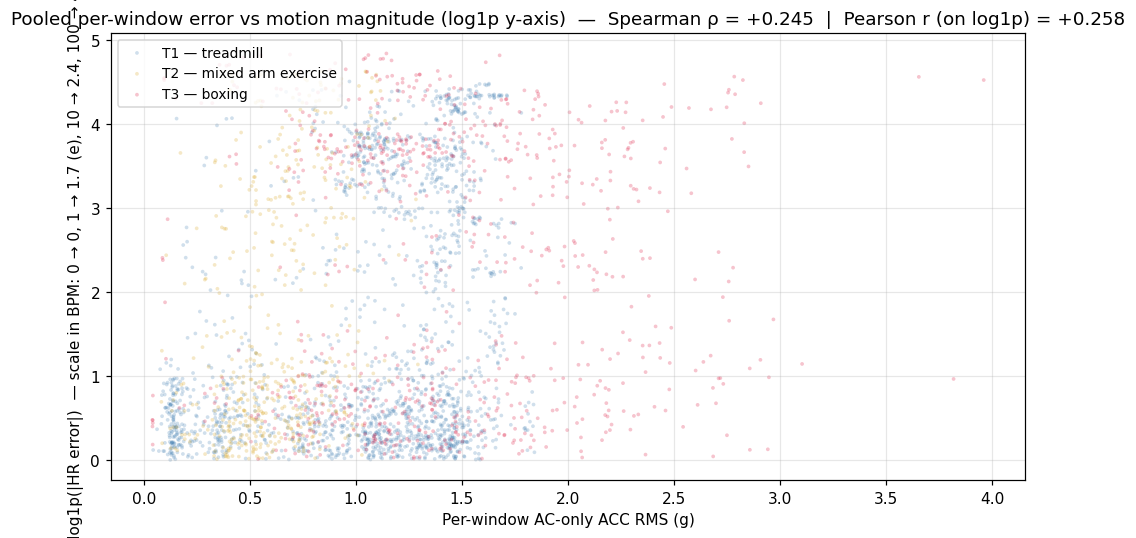

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for grp in ('T1', 'T2', 'T3'):
    mask = grp_per_win == grp
    ax.scatter(mag_per_win[mask], np.log1p(err_per_win[mask]),
               s=6, alpha=0.25, color=GROUP_COLORS[grp], edgecolors='none',
               label=GROUP_LABELS[grp])

r, _   = pearsonr(mag_per_win, np.log1p(err_per_win))
rho, _ = spearmanr(mag_per_win, err_per_win)   # log1p is monotonic so Spearman is unchanged

ax.set_xlabel('Per-window AC-only ACC RMS (g)')
ax.set_ylabel('log1p(|HR error|)  — scale in BPM: 0 → 0, 1 → 1.7 (e), 10 → 2.4, 100 → 4.6')
ax.set_title(f'Pooled per-window error vs motion magnitude (log1p y-axis)  —  Spearman ρ = {rho:+.3f}  |  Pearson r (on log1p) = {r:+.3f}')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
